### **Guía de ejercicios para Certamen 3**
Resuelva los siguientes problemas utilizando Numpy, Pandas y Matplotlib, y el archivo de datos *synthetic_football_position_dataset.csv*, usado en la resolución del Certamen 2. Deberá eligir el tipo de gráfico que considere más adecuado para responder cada pregunta.

---

#### **Ejercicios**

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

#### **1: Equipos y sus distancias recorridas**

1. Filtra los datos para incluir únicamente jugadores que han participado en al menos el 50% de los minutos totales jugados en un partido.
2. Clasifica a cada jugador según las distancias que recorren durante los partidos:
- Baja distancia: menos de 4 kms. por partido.
- Media distancia: entre 4 y 8 kms. por partido.
- Alta distancia: más de 8 kms. por partido.
3. Agrupa los datos por equipo y calcula cuántos jugadores de cada equipo pertenecen a cada categoría de distancia.
4. Crea una visualización que permita responder:
**¿Hay equipos que destacan por correr más o menos, durante sus partidos?**

,team,minutes_played,goals_scored,assists,passes_completed,tackles,saves,shots_on_target,distance_covered_km,interceptions
player_id,,,,,,,,,,
4,Team_E,82,0,0,0,0,7,0,0.0,0
8,Team_C,51,2,1,87,3,0,4,8.9,8
10,Team_E,63,1,0,93,0,0,3,12.4,0
11,Team_D,58,1,0,14,0,0,1,5.0,0
12,Team_C,55,1,0,0,0,8,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
495,Team_E,46,0,0,0,0,2,0,0.0,0
497,Team_C,61,0,0,89,4,0,2,9.7,0
498,Team_A,79,1,0,80,0,7,4,9.6,0


C:\Users\renat\AppData\Local\Temp\ipykernel_10052\1198579385.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jugadores["Categoria"]= pd.cut(df_jugadores["distance_covered_km"], bins=[-float("inf"), 4, 8, float("inf")], labels=["baja", "media", "alta"]) #pd.cut es una función de pandas que clasifica valores continuos en intervalos
C:\Users\renat\AppData\Local\Temp\ipykernel_10052\1198579385.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resultados= df_jugadores.groupby(["team", "Categoria"]).size().unstack(fill_value=0)


Categoria,baja,media,alta
team,,,
Team_A,16,16,20
Team_B,13,15,20
Team_C,13,10,17
Team_D,13,20,22
Team_E,17,14,12


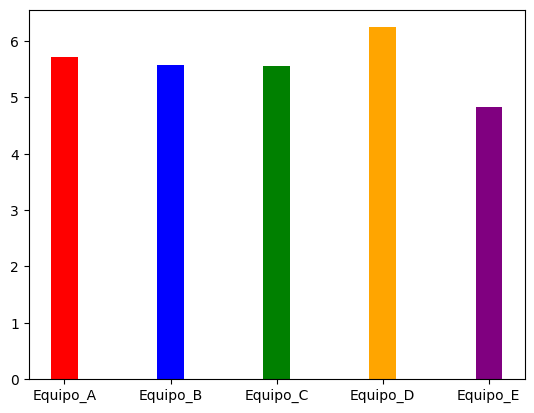

In [ ]:

df=pd.read_csv("synthetic_football_position_dataset.csv")
df=df.set_index("player_id")
df_jugadores=df[df["minutes_played"]>=45]
display(df_jugadores)

baja=df_jugadores[df_jugadores["distance_covered_km"]<4]
media=df_jugadores[(4<=df_jugadores["distance_covered_km"]) & (df_jugadores["distance_covered_km"]<=8)]
alta=df_jugadores[df_jugadores["distance_covered_km"]>8]

df2= pd.concat([baja[["team", "distance_covered_km"]], media[["team", "distance_covered_km"]], alta[["team", "distance_covered_km"]]])

Team_A= df2[df2["team"]=="Team_A"]
Team_B= df2[df2["team"]=="Team_B"]
Team_C= df2[df2["team"]=="Team_C"]
Team_D= df2[df2["team"]=="Team_D"]
Team_E= df2[df2["team"]=="Team_E"]

df_jugadores["Categoria"]= pd.cut(df_jugadores["distance_covered_km"], bins=[-float("inf"), 4, 8, float("inf")], labels=["baja", "media", "alta"]) #pd.cut es una función de pandas que clasifica valores continuos en intervalos
#-float("inf"): Representa el límite inferior infinito, incluye todos los valores menores a 4.
# el 4 y el 8 representan limite inferior y superior

resultados= df_jugadores.groupby(["team", "Categoria"]).size().unstack(fill_value=0)
#size() se utiliza para contar el número de ocurrencias en cada combinación de categorías
#unstack() toma el índice (en este caso, el resultado de groupby()) y lo convierte en columnas.

display(resultados)

Equipos=[Team_A["distance_covered_km"].mean(),Team_B["distance_covered_km"].mean(),Team_C["distance_covered_km"].mean(),Team_D["distance_covered_km"].mean(),Team_E["distance_covered_km"].mean()]

a=['Equipo_A', 'Equipo_B', 'Equipo_C', 'Equipo_D', 'Equipo_E']
colores = ['red', 'blue', 'green', 'orange', 'purple']

x= np.arange(len(a))
y= Equipos

Grafico= plt.bar(x,y,width=0.25, color=colores)
plt.xticks(x,a)
plt.show()




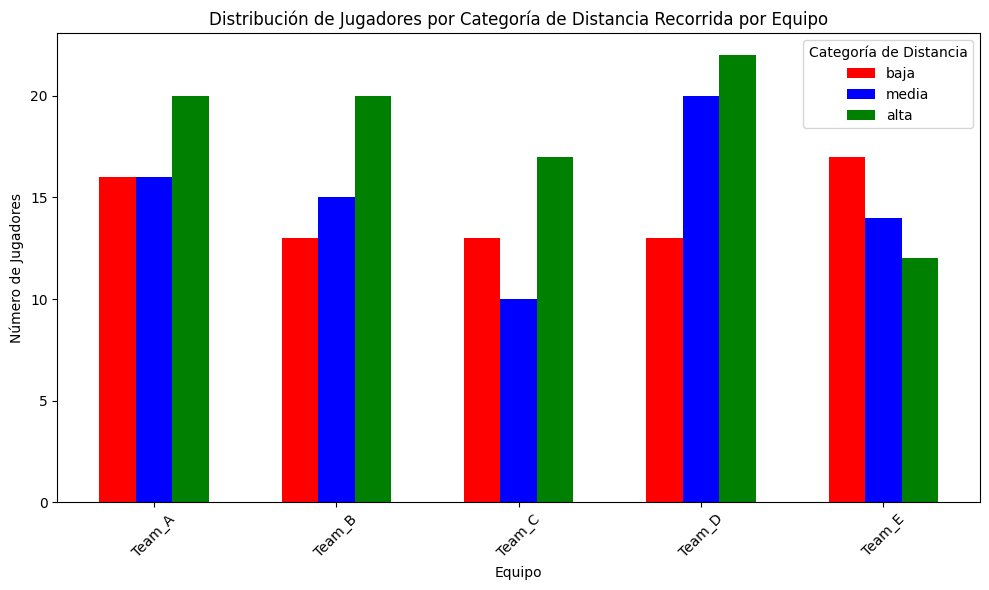

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ancho de las barras y posiciones en el eje X
x = np.arange(len(resultados.index)) # los equipos
ancho = 0.2  # Ancho de las barras

# Graficar las barras para cada categoría
for i, categoria in enumerate(resultados.columns): #las columnas;bajo;medio;alto
    ax.bar(x + i * ancho, resultados[categoria], ancho, label=categoria, color=colores[i])

# Añadir etiquetas y título
ax.set_xlabel("Equipo")
ax.set_ylabel("Número de Jugadores")
ax.set_title("Distribución de Jugadores por Categoría de Distancia Recorrida por Equipo")

# Configuración de las etiquetas del eje X
ax.set_xticks(x + ancho * (len(resultados.columns) / 2 - 0.5))  # Ajusta las posiciones de las etiquetas
ax.set_xticklabels(resultados.index)

# Añadir la leyenda
ax.legend(title="Categoría de Distancia")

# Mostrar el gráfico
plt.xticks(rotation=45)  # Rotar etiquetas de los equipos
plt.tight_layout()
plt.show()

Podemos ver que al filtrar los datos y sacar un promedio conseguimos poder ver que hay equpos que se destacan por correr mas y menos. En estos casos tenemos al equipo D el cual es el que sobresale
por correr mas y el equpo E se destaca por ser el que corre menos


#### **2: Relación entre pases, tiros y efectividad goleadora**

1. Filtra los datos para incluir únicamente jugadores con al menos 2 tiros al arco.

2. Calcula:
- El porcentaje de efectividad goleadora por equipo: 
(Goles anotados/Tiros al arco)×100
- El promedio de pases realizados por equipo.
3. Crea un gráfico que muestre la relación entre efectividad goleadora y promedio de pases realizados por equipo.
4. Responde:
**¿Existen patrones entre los equipos con alta efectividad goleadora y su capacidad para generar juego a través de pases?**


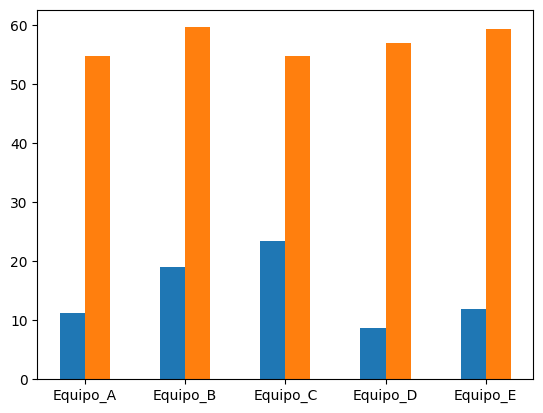

In [50]:
df_jugadores= df[df["shots_on_target"]>=2]

Team_A= df_jugadores[df_jugadores["team"]=="Team_A"]
Team_B= df_jugadores[df_jugadores["team"]=="Team_B"]
Team_C= df_jugadores[df_jugadores["team"]=="Team_C"]
Team_D= df_jugadores[df_jugadores["team"]=="Team_D"]
Team_E= df_jugadores[df_jugadores["team"]=="Team_E"]

por_A= ((Team_A["goals_scored"].sum()/Team_A["shots_on_target"].sum())*100)
pas_A= Team_A["passes_completed"].mean()

por_B= ((Team_B["goals_scored"].sum()/Team_B["shots_on_target"].sum())*100)
pas_B= Team_B["passes_completed"].mean()

por_C= ((Team_C["goals_scored"].sum()/Team_C["shots_on_target"].sum())*100)
pas_C= Team_C["passes_completed"].mean()

por_D= ((Team_D["goals_scored"].sum()/Team_D["shots_on_target"].sum())*100)
pas_D= Team_D["passes_completed"].mean()

por_E= ((Team_E["goals_scored"].sum()/Team_E["shots_on_target"].sum())*100)
pas_E= Team_E["passes_completed"].mean()

equipos= ['Equipo_A', 'Equipo_B', 'Equipo_C', 'Equipo_D', 'Equipo_E']

[por_A,por_B,por_C,por_D,por_E]


x= np.arange(len(equipos))
y1= [por_A,por_B,por_C,por_D,por_E]
y2= [pas_A,pas_B,pas_C,pas_D,pas_E]

ancho= 0.25

grafo1=plt.bar(x-ancho/2 , y1 , ancho)
grafo2=plt.bar(x+ancho/2 , y2 , ancho)
plt.xticks(x,equipos)
plt.show()


Podemos ver que en verdad no existe un patron consistente en relacion a pases completados y tiros a porteria, esto se puede deber a que si bien hay algunos equipos que poseen una mayor cantidad de pases completados que otros, no necesariamente estos muestran una mayor cantidad de tiros al arco

#### **3: Éxito por versatilidad de juego**

1. Clasifica a los jugadores según su versatilidad en el juego:
- Muy Versatil: Si tiene valores $> 0$ en cada una de las siguientes columnas; 'assists', 'passes_completed', 'tackles', y 'interceptions'.
- Versatil: Si tiene valores $> 0$ en 3 de las siguientes columnas; 'assists', 'passes_completed', 'tackles', y 'interceptions'.
- Normal: Si tiene valores $> 0$ en 2 de las siguientes columnas; 'assists', 'passes_completed', 'tackles', y 'interceptions'.
- No versatil: Si tiene un sólo un valor $> 0$ en alguna de las siguientes columnas; 'assists', 'passes_completed', 'tackles', y 'interceptions'.
2. Calcula el número de goles de cada equipo.
3. Agrupa cada equipo y cuenta cuántos jugadores de cada categoría de versatilidad tienen.
3. Crea un gráfico que muestre la relación entre: los niveles de versatilidad del equipo y el promedio de goles.
4. Responde: **¿Hay relación entre versatilidad y efectividad?**


,team,minutes_played,goals_scored,assists,passes_completed,tackles,saves,shots_on_target,distance_covered_km,interceptions,versatilidad
player_id,,,,,,,,,,,
1,Team_D,33,0,0,57,3,0,0,8.4,6,versatil
2,Team_E,7,1,0,74,0,0,2,9.2,0,no_versatil
3,Team_C,39,2,0,56,0,5,3,5.5,0,no_versatil
4,Team_E,82,0,0,0,0,7,0,0.0,0,NaN
5,Team_E,41,0,0,47,9,0,0,9.9,3,versatil
...,...,...,...,...,...,...,...,...,...,...,...
496,Team_A,11,0,0,91,7,0,0,10.8,7,versatil
497,Team_C,61,0,0,89,4,0,2,9.7,0,normal
498,Team_A,79,1,0,80,0,7,4,9.6,0,no_versatil


team
Team_A    21
Team_B    34
Team_C    28
Team_D    26
Team_E    20
Name: goals_scored, dtype: int64

versatilidad,muy_versatil,no_versatil,normal,versatil
team,,,,
Team_A,0.5,0.450000,0.600000,0.061224
Team_B,0.0,0.818182,0.857143,0.073171
Team_C,0.6,0.777778,0.600000,0.102564
Team_D,0.0,0.466667,0.285714,0.042553
Team_E,0.0,0.470588,0.375000,0.027778


team    versatilidad
Team_A  versatil        49
        no_versatil     20
        normal           5
        muy_versatil     2
Team_B  versatil        41
        no_versatil     22
        normal           7
        muy_versatil     1
Team_C  versatil        39
        no_versatil     18
        muy_versatil     5
        normal           5
Team_D  versatil        47
        no_versatil     30
        normal           7
        muy_versatil     4
Team_E  versatil        36
        no_versatil     17
        normal           8
        muy_versatil     2
Name: count, dtype: int64

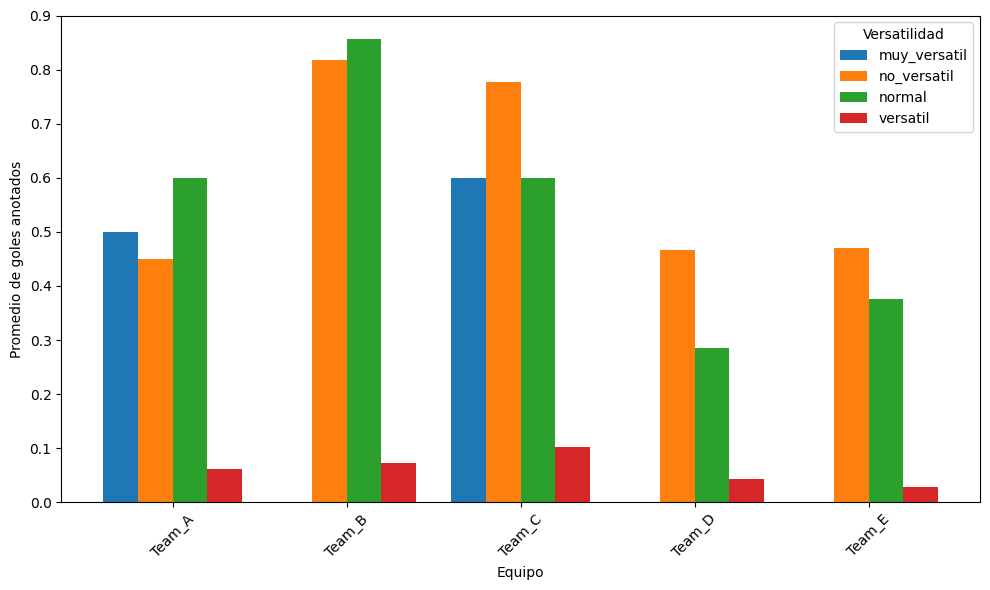

In [ ]:
display(df)

df["versatilidad"]= (df[["assists", "passes_completed", "tackles", "interceptions"]]>0).sum(axis=1)
df["versatilidad"] = df["versatilidad"].map({4: "muy_versatil", 3: "versatil", 2: "normal", 1: "no_versatil"}) #parametro para la versatilidad

grupo= df.groupby("team")
goles= grupo["goals_scored"].sum() #agrupamos los equipos con la suma de sus goles
display(goles)

# Calcular el promedio de goles por equipo y categoría de versatilidad
promedio= df.groupby(["team", "versatilidad"])["goals_scored"].mean().unstack(fill_value=0)
display(promedio)

versatilidad= grupo["versatilidad"].value_counts()
display(versatilidad) #mostrar cantidad de jugadores en cada versatilidad

fig,ax = plt.subplots(figsize=(10,6)) 
#plt.subplots(): Esta función crea una figura (fig) y un conjunto de ejes (ax) donde se dibujarán los gráficos.

x = np.arange(len(promedio.index))
#La longitud de promedio.index es el número de filas en el DataFrame promedio. 
#En este caso, representa el número de equipos.
ancho= 0.2

for i, col in enumerate(promedio.columns):
    ax.bar(x+i*ancho, promedio[col], ancho, label= col)

#Itera sobre las columnas de promedio. Aquí, cada columna representa una categoría de "versatilidad" (por ejemplo, "muy_versatil", "versatil", etc.).
#i: Es el índice de la columna (un número que empieza en 0 y aumenta en 1 con cada iteración).
#col: Es el nombre de la columna que se está iterando (por ejemplo, "muy_versatil").
#promedio[col]: Los valores de la columna col de promedio, que representan el valor de "promedio de goles anotados" para cada equipo en esa categoría.
#label=col: Establece la etiqueta para la leyenda. Cada categoría (versatilidad) tendrá una barra con su nombre en la leyenda.

ax.set_xlabel("Equipo")
ax.set_ylabel("Promedio de goles anotados")
ax.set_xticks(x + ancho * (len(promedio.columns) / 2 - 0.5))
ax.set_xticklabels(promedio.index)
ax.legend(title="Versatilidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Podemos ver que en general no necesariamente debe existir relacion entre versatilidad y efectividad ya que si bien algunos pueden tener mas rasgos que otros no necesariamente son mas efectivo
dado que algunos pueden tener menos rasgos pero mas efectivos en sus areas